#**Car Events Detection**

Detect cars related events on the road, such as exit taken, crowd levels, and the duration each car spend on the road.

#Table of Contents
1.   Environment Setup
2.   Import libraries
3.   Frame Selection
4.   objects Detection
5.   Detection and counting in specific region
6.   Run The Full Code
7.   Data Overview
8.   Handling duplicated data
9.   Rounding the values
10.   Saving the Data








In [3]:
!git clone --recurse-submodules https://github.com/mikel-brostrom/boxmot.git

Cloning into 'boxmot'...
remote: Enumerating objects: 18929, done.
remote: Counting objects: 100% (700/700), done.
remote: Compressing objects: 100% (363/363), done.
remote: Total 18929 (delta 497), reused 382 (delta 326), pack-reused 18229 (from 3)
Receiving objects: 100% (18929/18929), 129.58 MiB | 13.92 MiB/s, done.
Resolving deltas: 100% (12122/12122), done.


##1.Environment Setup

In [4]:
!pip install -U supervision

In [5]:
pip install ultralytics

In [6]:
pip install boxmot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 131.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 22.9 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=071dafcd4526621a676a96cff19fb55a4c1158d4e5a96fbb042ff4928dbebdcc
  Stored in directory: /root/.cache/pip/wheels/12/dc/3c/e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy


In [7]:
pip install db-sqlite3

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for db-sqlite3: filename=db_sqlite3-0.0.1-py3-none-any.whl size=1768 sha256=84eb00c44f0a7684cbc586b45f7a5ab34c815dfead6bc4975de3eb03b2577583
  Stored in directory: /root/.cache/pip/wheels/d2/76/f8/d078e1609571cb2d847296a2bb130a355498554aa647e957ba
  Created wheel for db: filename=db-0.1.1-py3-none-any.whl size=3873 sha256=990776f3756c91092950ab192510ab9c0823c3a7189e51ba7424fe0c885aef8d
  Stored in directory: /root/.cache/pip/wheels/1f/a9/df/8e343ae1489f35fa96888200ee3340217512b98bed2c2def2d
  Created wheel for antiorm: filename=antiorm-1.2.1-py3-none-any.whl size=31666 sha256=5c0a1b888e4ac393c9ea9261e393c87d358512d4c5e4058fa38ad44212c2e8d9
  Stored in directory: /root/.cache/pip/wheels/71/04/d9/c9b4297ae902eb961bc1cff29b248a7e706693200ef2656fb2
Successfully built db-sql

In [8]:
!nvidia-smi

Thu Jul 24 11:21:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##2.Import libraries

In [9]:
from ultralytics import YOLO
import cv2
import supervision as sv
import numpy as np
import pandas as pd
import sqlite3
import datetime
from pathlib import Path
from boxmot.trackers.strongsort.strongsort import StrongSort

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [10]:
def crowdLevel(count):
  if count>=15:
      crowd='high'
  elif count>=9 and count<15:
      crowd='medium'
  else:
      crowd='low'
  return crowd

##3. Frame Selection



In [11]:
video_path=r'/content/Project Name 1.mov'

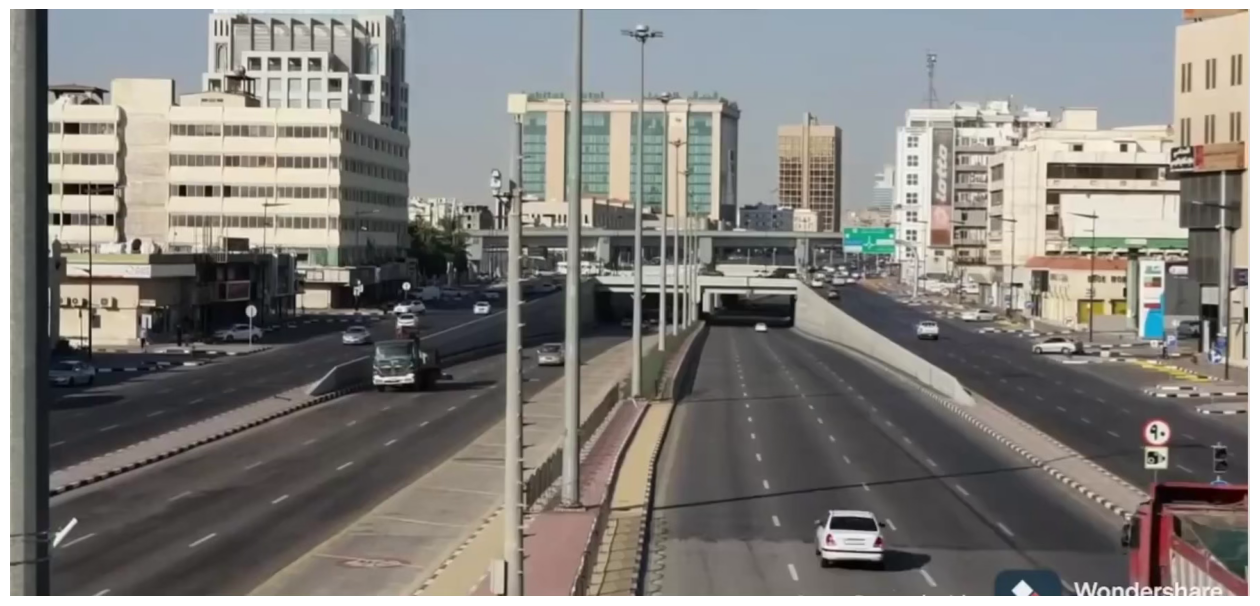

In [12]:
generator = sv.get_video_frames_generator(video_path)
iterator=iter(generator)
frame= next(iterator)
#frame = cv2.resize(frame, (1020, 500))

sv.plot_image(frame,(16,16))

##4. objects Detection

In [13]:
model=YOLO('yolov8x.pt')

100%|██████████| 131M/131M [00:00<00:00, 420MB/s] 



0: 320x640 7 cars, 2 trucks, 82.7ms
Speed: 9.4ms preprocess, 82.7ms inference, 394.7ms postprocess per image at shape (1, 3, 320, 640)


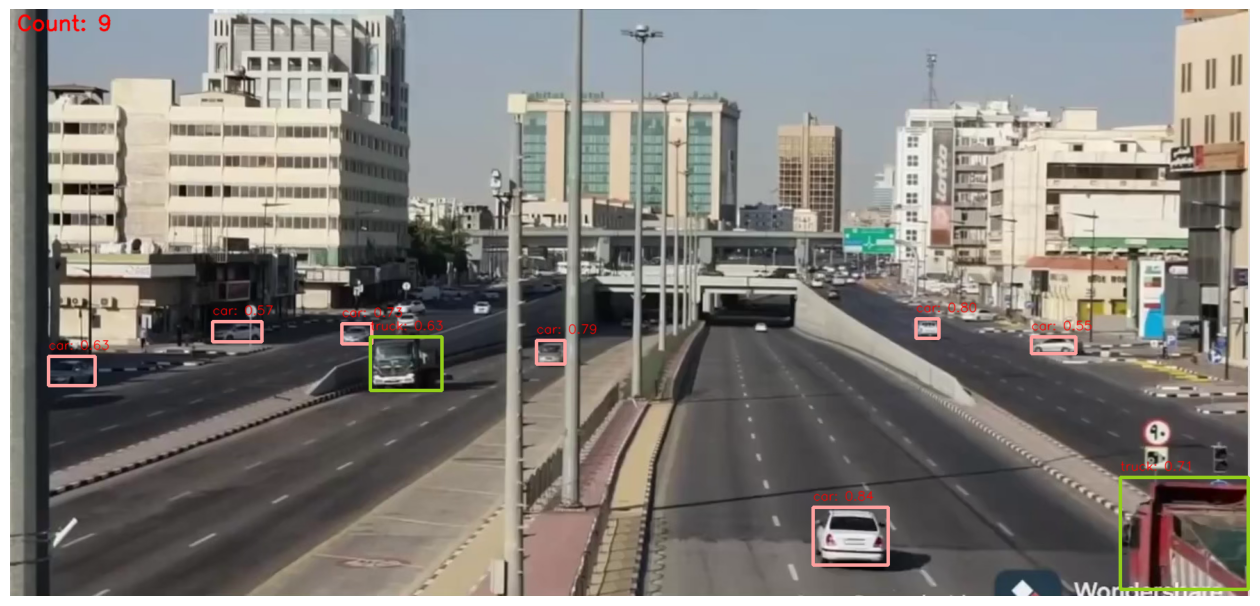

In [14]:
result= model(frame,imgsz=640,conf=0.5,iou=0.5,classes=[2, 3, 5, 7])[0]

detection = sv.Detections.from_ultralytics(result)
detection = detection[(np.isin(detection.class_id,[2,3,5,7]))& (detection.confidence > 0.3)]


#print(f'The total number of detcted vehicles: {len(detection)}')
count = len(detection)
cv2.putText(frame, f'Count: {count}', (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)



labels= [f'{result.names[class_id]}: {confidence:.2f}'
         for class_id,confidence in zip(detection.class_id, detection.confidence) ]


detection.data["labels"] = labels

annotator = sv.BoxAnnotator(thickness=3)
frame=annotator.annotate(scene=frame, detections= detection)

# Add text labels manually
for box, label in zip(detection.xyxy, labels):
    x1, y1, x2, y2 = map(int, box)
    cv2.putText(frame, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 1, cv2.LINE_AA)


sv.plot_image(frame,(16,16))

##5. Detection and counting in specific region ROI resdgion of intrest


0: 320x640 9 cars, 1 truck, 51.7ms
Speed: 2.9ms preprocess, 51.7ms inference, 2.4ms postprocess per image at shape (1, 3, 320, 640)
Object 1 entered zone 0
Object 2 entered zone 1


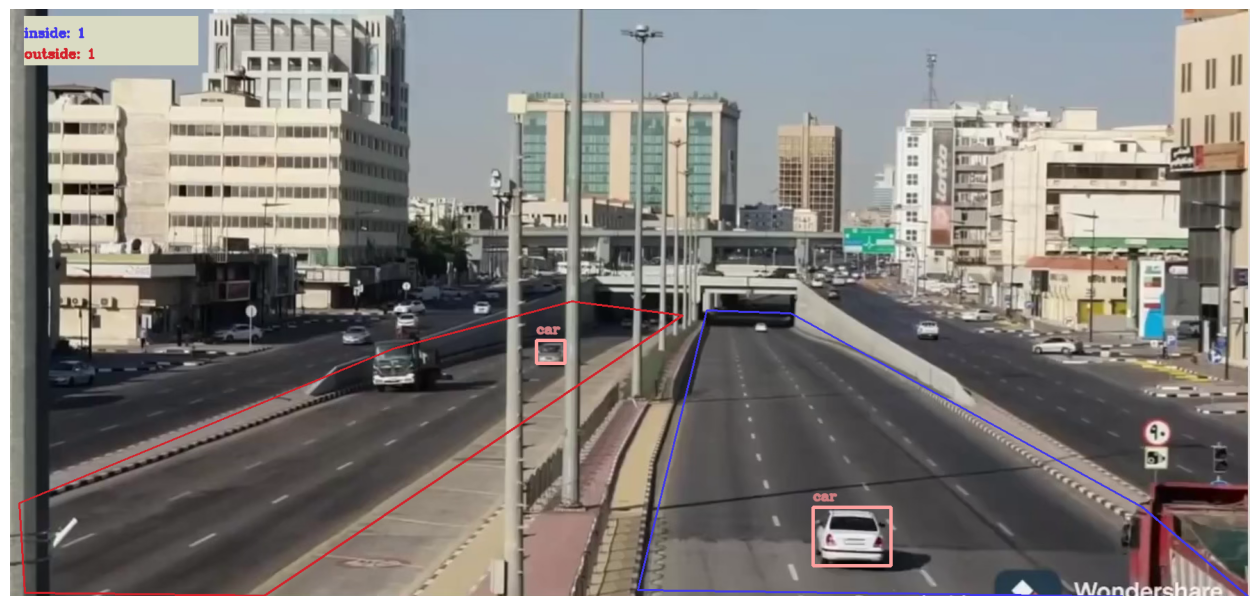

In [15]:
inside=np.array([[903,835], [1002,433], [1123,437], [1629,716], [1784,847]], dtype=np.int64)
outside=np.array([[808, 420], [967,440], [366,843], [21,839], [13,710],[551, 488]], dtype=np.int64)

zones=[np.array([[903,835], [1002,433], [1123,437], [1629,716], [1784,847]], dtype=np.int64),
np.array([[808, 420], [967,440], [366,843], [21,839], [13,710],[551, 488]], dtype=np.int64)]

polygon_zones = [sv.PolygonZone(polygon=zone) for zone in zones] #convert to polygon object
zone_counts = [set(), set()]

colors=sv.ColorPalette.DEFAULT
tracker = sv.ByteTrack()

generator = sv.get_video_frames_generator(video_path)
iterator=iter(generator)
frame= next(iterator)
image=frame
height,width,channels=image.shape


annotator= sv.BoxAnnotator(thickness=3)

cv2.polylines(frame, [inside], isClosed=True, color=(235, 56, 65), thickness=2)
cv2.polylines(frame, [outside], isClosed=True, color=(43, 34, 212), thickness=2)

result= model(frame,imgsz=640)[0]
detection=sv.Detections.from_ultralytics(result)

detection = detection[(np.isin(detection.class_id, [2,3,5,7])) & (detection.confidence > 0.3)]

mask = np.zeros(len(detection), dtype=bool)

for zone in polygon_zones:
                zone_mask = zone.trigger(detections=detection)
                mask = mask | zone_mask

for zone in polygon_zones:
                zone.trigger(detections=detection)

detection = detection[mask]



detection = tracker.update_with_detections(detection)

for i in range(len(detection)):
    tracker_id = int(detection.tracker_id[i])
    x_min, y_min, x_max, y_max = detection.xyxy[i]
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    center = (int(center_x), int(center_y))
    for zone_index, polygon in enumerate(zones):
        if cv2.pointPolygonTest(polygon.astype(np.int32), center, False) >= 0:
          if tracker_id not in zone_counts[zone_index]:
            zone_counts[zone_index].add(tracker_id)
            print(f"Object {tracker_id} entered zone {zone_index}")

#count = len(detection)


label_anootate= sv.LabelAnnotator()

labels = [result.names[class_id] for class_id in detection.class_id]
detection.data["labels"] = labels

frame = annotator.annotate(scene=frame, detections=detection)


# Add text labels manually
for box, label in zip(detection.xyxy, labels):
    x1, y1, x2, y2 = map(int, box)
    cv2.putText(frame, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_COMPLEX, 0.6, (130, 126, 207), 2, cv2.LINE_AA)


legend_x, legend_y = 20, 40
cv2.rectangle(frame, (legend_x, legend_y - 30), (legend_x + 250, legend_y + 40), (195, 219, 218), -1)
cv2.putText(frame, f"inside: {len(zone_counts[0])}", (legend_x, legend_y),cv2.FONT_HERSHEY_COMPLEX, 0.6, (235, 56, 65), 2)
cv2.putText(frame, f"outside: {len(zone_counts[1])}", (legend_x, legend_y + 30),cv2.FONT_HERSHEY_COMPLEX, 0.6, (43, 34, 212), 2)



sv.plot_image(frame,(16,16))

##6. Run The Full Code

In [16]:
def ccw(A, B, C):
    value = (C[1]-A[1])*(B[0]-A[0]) - (B[1]-A[1])*(C[0]-A[0])
    return 1 if value > 1e-5 else -1 if value < -1e-5 else 0

def crosses_line(p1, p2, line):
    A, B = line
    return (ccw(A, B, p1) != ccw(A, B, p2) and ccw(p1, p2, A) != ccw(p1, p2, B))


In [17]:
label_annotator = sv.LabelAnnotator(text_scale=0.4, text_thickness=1)

zone_counts = [set(), set()]
class_names = model.names
frame_index = 0
collectedData=[]
line1_crossed = {}
line2_crossed = {}
prev_centers = {}
tracker_speeds = {}
directions={}
distance = 60
line1 = [(33,701), (1648,716)]
line2 = [(1367,561), (373, 561)]
fps = 30



def make_process_frame(zones, box_annotators, tracker):
    def process_frame(frame: np.ndarray, i) -> np.ndarray:
        global frame_index
        results= model(frame,imgsz=1280,conf=0.5,iou=0.5,classes=[2,3,5,7],verbose=False)[0]
        detection = sv.Detections.from_ultralytics(results)
        detection = detection[(np.isin(detection.class_id, [2,3,5,7])) & (detection.confidence > 0.5)]

        mask = np.zeros(len(detection), dtype=bool)
        for zone in polygon_zones:
            zone_mask = zone.trigger(detections=detection)
            mask |= zone_mask
        detections_filtered = detection[mask]

# If none are inside zones, skip further processing
        if len(detections_filtered) == 0:
            frame_index += 1
            return frame

        dets_array = np.hstack([ detections_filtered.xyxy, detections_filtered.confidence[:, np.newaxis],
            detections_filtered.class_id[:, np.newaxis].astype(float)])

        updated_dets_array = tracker.update(dets_array, frame)

        # Convert back to sv.Detections format
        if updated_dets_array.size > 0:
            detections_filtered = sv.Detections(
                xyxy=updated_dets_array[:, :4],
                confidence=updated_dets_array[:, 5],
                class_id=updated_dets_array[:, 6].astype(int),
                tracker_id=updated_dets_array[:, 4].astype(int)
            )
        else:
            detections_filtered = sv.Detections.empty()


        count = len(detections_filtered)

        #cv2.polylines(frame, [inside], isClosed=True, color=(235, 56, 65), thickness=2)
        #cv2.polylines(frame, [outside], isClosed=True, color=(43, 34, 212), thickness=2)

        frame = box_annotators.annotate(scene=frame, detections=detections_filtered)
        direction = 'unknown'
        for j in range(len(detections_filtered)):
            class_id = int(detections_filtered.class_id[j])
            class_name = class_names[class_id]
            confidence = float(detections_filtered.confidence[j])
            tracker_id = int(detections_filtered.tracker_id[j])

            timestamp = str(datetime.timedelta(seconds=round(frame_index/30))) #stored as mm:ss
            x_min, y_min, x_max, y_max = map(float, detections_filtered.xyxy[j])
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center = (int(center_x), int(center_y))


            if tracker_id not in prev_centers:
                prev_centers[tracker_id] = center

            if tracker_id in prev_centers:
                if crosses_line(prev_centers[tracker_id], center, line1)and tracker_id not in line1_crossed:
                    line1_crossed[tracker_id] = frame_index

                if (crosses_line(prev_centers[tracker_id], center, line2)and tracker_id not in line2_crossed):
                    line2_crossed[tracker_id] = frame_index

            prev_centers[tracker_id] = center


            if tracker_id in line1_crossed and tracker_id in line2_crossed:
                global speed_kmph
                frame_diff = line2_crossed[tracker_id] - line1_crossed[tracker_id]
                if frame_diff < 0:
                    direction = 'Outside'
                    zone_counts[1].add(tracker_id)
                elif frame_diff > 0:
                    direction = 'inside'
                    zone_counts[0].add(tracker_id)
                time_sec = abs(float(frame_diff)) / float(fps)
                speed_kmph = (float(distance) * 3.6)/ float(time_sec)

                print(f"Tracker {tracker_id}: Speed = {speed_kmph:.2f} km/h")
                tracker_speeds[tracker_id] = speed_kmph
                directions[tracker_id] = direction
                del line1_crossed[tracker_id]
                del line2_crossed[tracker_id]

            crowd = crowdLevel(count)

            speed = tracker_speeds.get(tracker_id, None)
            direction = directions.get(tracker_id, "unknown")
            collectedData.append({'tracker_id': tracker_id,'class_id': class_id,'class_name': class_name,'confidence': confidence,'timestamp': timestamp,
                      'direction': direction,'count': count,'crowd': crowd,'x_min': x_min,'y_min': y_min,'x_max': x_max,'y_max': y_max,'speed_kmph': speed  })


        labels = []
        for j in range(len(detections_filtered)):
          tracker_id = int(detections_filtered.tracker_id[j]) if detections_filtered.tracker_id is not None else None
          class_id = int(detections_filtered.class_id[j])

          speed_text = ""
          if tracker_id in tracker_speeds:
            speed_text = f" {tracker_speeds[tracker_id]:.1f} km/h"

          label = f"{class_names[class_id]}{speed_text}"
          labels.append(label)

        detections_filtered.data["labels"] = labels
        frame = label_annotator.annotate(scene=frame, detections=detections_filtered, labels=labels)

        legend_x, legend_y = 20, 40
        cv2.rectangle(frame, (legend_x, legend_y - 30), (legend_x + 250, legend_y + 40), (195, 219, 218), -1)
        cv2.putText(frame, f"inside: {len(zone_counts[0])}", (legend_x, legend_y),
            cv2.FONT_HERSHEY_COMPLEX, 0.6, (235, 56, 65), 2)
        cv2.putText(frame, f"outside: {len(zone_counts[1])}", (legend_x, legend_y + 30),
            cv2.FONT_HERSHEY_COMPLEX, 0.6, (43, 34, 212), 2)
        cv2.line(frame, line1[0], line1[1], (0, 255, 0), 2)
        cv2.line(frame, line2[0], line2[1], (0, 255, 255), 2)


        frame_index +=1
        return frame
    return process_frame

In [18]:
tracker = StrongSort(
    reid_weights=Path("/content/osnet_x1_0_msmt17.pt"),
    device="0",half=False,
    per_class=False, max_age=30)


process_frame_fn = make_process_frame(zones, annotator,tracker)

sv.process_video(
    source_path=video_path,
    target_path="result.mp4",
    callback=process_frame_fn
)

2025-07-24 11:21:37.052 | INFO     | boxmot.utils.torch_utils:select_device:78 - Yolo Tracking v15.0.1 🚀 Python-3.11.13 torch-2.6.0+cu124
CUDA:0 (Tesla T4, 15095MiB)
2025-07-24 11:21:37.053 | INFO     | boxmot.appearance.backends.base_backend:download_model:138 - Downloading ReID weights from %s → %s
Downloading...
From: https://drive.google.com/uc?id=112EMUfBPYeYg70w-syK6V6Mx8-Qb9Q1M
To: /content/osnet_x1_0_msmt17.pt
100%|██████████| 11.0M/11.0M [00:00<00:00, 22.9MB/s]
2025-07-24 11:21:41.724 | SUCCESS  | boxmot.appearance.reid.registry:load_pretrained_weights:64 - Loaded pretrained weights from /content/osnet_x1_0_msmt17.pt


Tracker 1: Speed = 70.43 km/h
Tracker 4: Speed = 90.00 km/h
Tracker 7: Speed = 41.81 km/h
Tracker 8: Speed = 62.31 km/h
Tracker 26: Speed = 90.00 km/h
Tracker 29: Speed = 99.69 km/h
Tracker 36: Speed = 120.00 km/h
Tracker 37: Speed = 101.25 km/h
Tracker 38: Speed = 78.07 km/h
Tracker 49: Speed = 70.43 km/h
Tracker 61: Speed = 66.80 km/h
Tracker 67: Speed = 75.35 km/h
Tracker 83: Speed = 99.69 km/h
Tracker 77: Speed = 70.43 km/h
Tracker 85: Speed = 91.27 km/h
Tracker 88: Speed = 96.72 km/h
Tracker 56: Speed = 79.02 km/h
Tracker 101: Speed = 83.08 km/h
Tracker 102: Speed = 101.25 km/h
Tracker 104: Speed = 85.26 km/h
Tracker 108: Speed = 115.71 km/h
Tracker 95: Speed = 108.00 km/h
Tracker 112: Speed = 96.72 km/h
Tracker 122: Speed = 93.91 km/h
Tracker 125: Speed = 95.29 km/h
Tracker 132: Speed = 108.00 km/h
Tracker 138: Speed = 95.29 km/h
Tracker 136: Speed = 62.31 km/h


##7. Data Overview

In [19]:
carsDf = pd.DataFrame(collectedData)

In [20]:
carsDf['tracker_id'].value_counts()

,count
tracker_id,
2,1309
7,643
101,538
26,503
61,478
...,...
103,2
107,2
50,1


In [21]:
carsDf['speed_kmph'].value_counts()

,count
speed_kmph,
41.806452,461
83.076923,446
90.000000,437
96.716418,396
115.714286,388
66.804124,360
62.307692,277
70.434783,259
85.263158,230


In [22]:
carsDf['direction'].value_counts()

,count
direction,
unknown,6525
inside,3435
Outside,262


The data should only have 2663 instance

In [23]:
carsDf.shape

(10222, 13)

there is 795798 instance and 12 features, most of the instances are duplicated values

##8.Handling duplicated data

In [24]:
trakerIdList= carsDf['tracker_id'].unique().tolist()  #save all the tracker ids in a list

###Create a function to unify the data of each object

In [25]:
def custom_selector(carsDf,trakerIdList):
  newDf = pd.DataFrame(columns=carsDf.columns)
  for i in trakerIdList:
    df=carsDf[carsDf['tracker_id']==i].copy()   #create a copy for each car
    if (df['class_name'].nunique() > 1): #check if it has more than one class
      df['class_name']= str(df['class_name'].mode().iloc[0])
    if not (df[df['direction']== 'unknown'].empty):
      direction = df['direction'][df['direction'] != 'unknown']
      if not direction.empty:
        df['direction'] = df['direction'].replace('unknown', direction.iloc[-1])
    speed = df['speed_kmph'].dropna()
    if not speed.empty:
      df['speed_kmph'] = speed.iloc[-1]


    '''df = df.sort_values('timestamp') #calcuate the duration for each car
    df['duration']= float(df['timestamp'].iloc[-1])-float(df['timestamp'].iloc[0])'''
    copytime = pd.to_timedelta(df['timestamp'])
    copytime = copytime.sort_values()
    duration_seconds= (copytime.iloc[-1]-copytime.iloc[0]).total_seconds()
    formatted = str(datetime.timedelta(seconds=duration_seconds))
    df['duration'] = formatted


    newDf = pd.concat([newDf, df], ignore_index=True)
  return newDf

In [26]:
CarsDf = custom_selector(carsDf, trakerIdList)
CarsDf.drop_duplicates(subset='tracker_id', keep='first',inplace=True)

In [27]:
CarsDf.sort_values('tracker_id')

,tracker_id,class_id,class_name,confidence,timestamp,direction,count,crowd,x_min,y_min,x_max,y_max,speed_kmph,duration
0,1,2,car,0.871539,0:00:00,inside,6,low,1152.641487,709.980891,1252.879373,790.178326,70.434783,0:00:12
326,2,7,truck,0.756122,0:00:00,unknown,6,low,520.660885,475.287998,625.410440,551.842810,NaN,0:00:46
1635,3,2,car,0.716057,0:00:00,unknown,6,low,1071.840942,451.787126,1090.295084,465.147768,NaN,0:00:01
1657,4,2,car,0.662434,0:00:00,Outside,6,low,754.495456,481.669289,797.118628,515.899997,90.000000,0:00:06
1793,5,7,truck,0.653383,0:00:00,unknown,6,low,1587.434162,672.190675,1778.283099,841.332104,NaN,0:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10098,141,2,car,0.700877,0:00:44,unknown,10,medium,794.581786,463.603863,815.714814,498.962807,NaN,0:00:01
10143,143,2,car,0.572304,0:00:44,unknown,10,medium,871.185587,438.179836,895.190234,457.473101,NaN,0:00:02
10188,145,2,car,0.535428,0:00:45,unknown,10,medium,721.178675,464.400949,771.026663,507.121530,NaN,0:00:01
10198,146,2,car,0.860546,0:00:46,unknown,8,low,1203.078575,722.738010,1316.474449,815.890374,NaN,0:00:00


In [28]:
CarsDf.reset_index(drop=True,inplace =True)

In [29]:
CarsDf = CarsDf.dropna(subset=['speed_kmph'])

##9.Rounding the values

In [30]:
CarsDf

,tracker_id,class_id,class_name,confidence,timestamp,direction,count,crowd,x_min,y_min,x_max,y_max,speed_kmph,duration
0,1,2,car,0.871539,0:00:00,inside,6,low,1152.641487,709.980891,1252.879373,790.178326,70.434783,0:00:12
3,4,2,car,0.662434,0:00:00,Outside,6,low,754.495456,481.669289,797.118628,515.899997,90.000000,0:00:06
6,7,7,truck,0.722594,0:00:01,inside,4,low,1522.141431,633.837871,1781.451415,844.006648,41.806452,0:00:22
7,8,2,car,0.818755,0:00:03,inside,5,low,1270.881736,709.909135,1412.323105,822.797582,62.307692,0:00:13
18,26,7,car,0.629841,0:00:09,inside,7,low,1333.135103,706.775459,1460.219284,827.961544,90.000000,0:00:17
19,29,2,car,0.646529,0:00:10,Outside,7,low,668.815329,527.676803,712.163929,565.775782,99.692308,0:00:03
22,36,2,car,0.648125,0:00:11,Outside,8,low,678.697260,513.096827,720.393432,559.110221,120.000000,0:00:03
23,37,2,car,0.689486,0:00:12,Outside,8,low,680.795157,499.971408,722.096104,535.060395,101.250000,0:00:04
24,38,2,car,0.624890,0:00:12,Outside,10,medium,695.137174,480.397900,724.622454,511.705660,78.072289,0:00:06
30,49,2,car,0.678717,0:00:14,Outside,10,medium,668.288366,516.408759,705.773617,555.973820,70.434783,0:00:06


In [31]:
CarsDf['confidence']=CarsDf['confidence'].round(2)
CarsDf['x_min']=CarsDf['x_min'].round(2)
CarsDf['y_min']=CarsDf['y_min'].round(2)
CarsDf['x_max']=CarsDf['x_max'].round(2)
CarsDf['y_max']=CarsDf['y_max'].round(2)

#CarsDf['speed_kmph'] = pd.to_numeric(CarsDf['speed_kmph'])
CarsDf['speed_kmph'] = CarsDf['speed_kmph'].round(2)



CarsDf

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

,tracker_id,class_id,class_name,confidence,timestamp,direction,count,crowd,x_min,y_min,x_max,y_max,speed_kmph,duration
0,1,2,car,0.87,0:00:00,inside,6,low,1152.64,709.98,1252.88,790.18,70.43,0:00:12
3,4,2,car,0.66,0:00:00,Outside,6,low,754.50,481.67,797.12,515.90,90.00,0:00:06
6,7,7,truck,0.72,0:00:01,inside,4,low,1522.14,633.84,1781.45,844.01,41.81,0:00:22
7,8,2,car,0.82,0:00:03,inside,5,low,1270.88,709.91,1412.32,822.80,62.31,0:00:13
18,26,7,car,0.63,0:00:09,inside,7,low,1333.14,706.78,1460.22,827.96,90.00,0:00:17
19,29,2,car,0.65,0:00:10,Outside,7,low,668.82,527.68,712.16,565.78,99.69,0:00:03
22,36,2,car,0.65,0:00:11,Outside,8,low,678.70,513.10,720.39,559.11,120.00,0:00:03
23,37,2,car,0.69,0:00:12,Outside,8,low,680.80,499.97,722.10,535.06,101.25,0:00:04
24,38,2,car,0.62,0:00:12,Outside,10,medium,695.14,480.40,724.62,511.71,78.07,0:00:06
30,49,2,car,0.68,0:00:14,Outside,10,medium,668.29,516.41,705.77,555.97,70.43,0:00:06


##10. Saving the data

In [32]:
CarsDf.to_csv("CleanedData.csv", index=False)
#whole data
#carsDf.to_csv("allData.csv", index=False)
conn = sqlite3.connect('DetectedCarsUpadated.db')
CarsDf.to_sql('cars', conn, if_exists='replace', index=False)

28

In [33]:
from google.colab import files
#save the result video
files.download('result.mp4')
#save the database
files.download('DetectedCarsUpadated.db')

#save as csv
files.download('CleanedData.csv')
#files.download('allData.csv')
conn.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>